# Analyse network

## Setup and helpers

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Add scripts directory to path for imports
sys.path.insert(0, str(Path("../scripts").resolve()))

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import yaml

pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 50)

# Load the network
network_path = "networks/base_s_adm___2050.nc"
config_path = "configs/config.base_s_adm___2050.yaml"

n = pypsa.Network(network_path)

with open(config_path) as f:
    config = yaml.safe_load(f)

# Extract tech colors from config
tech_colors = {}
if "techs" in config:
    for tech in config["techs"]:
        tech_colors[tech] = config["techs"][tech].get("color", "#888888")

# Calculate statistics
stats = n.statistics

# Load plotting colors
with open("../../../config/plotting.default.yaml") as f:
    pypsa_carrier_colors = yaml.safe_load(f)["plotting"]["tech_colors"]

print(f"Network loaded: {network_path}")
print(f"Config loaded: {config_path}")

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
Index(['EU methanol import', 'EU oil import', 'EU gas import'], dtype='object', name='name')
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


Network loaded: networks/base_s_adm___2050.nc
Config loaded: configs/config.base_s_adm___2050.yaml


### Helpers

In [2]:
from typing import cast


def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    show_legend=True,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters
    ----------
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    - show_legend: bool, whether to display the legend (default True)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0

        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            assert isinstance(data, pd.Series)  # type guard for Pylance
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()  # type: ignore[union-attr]

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                assert isinstance(data, pd.Series)  # type guard for Pylance
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]  # type: ignore[index]

            series = series.dropna()

            # Split into positive and negative values (keep zeros with positives)
            pos_series = series[series >= 0].sort_values(ascending=False)
            neg_series = series[series < 0].sort_values(ascending=True)  # Sort ascending for leftward stacking

            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}

            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()

                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height,
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)

            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())

                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height,
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)

            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    else:
        # Single bar (original behavior)
        legend_handles = {}
        _plot_single_bar(
            data,
            ax,
            0,
            tech_colors,
            nice_names,
            annotate_thresh,
            bar_height,
            legend_handles,
            annotate_decimals,
        )
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if show_legend and legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)


def enforce_common_xlim(axes, data_list, pad_fraction=0.05):
    """
    Enforce a common x-axis limit across multiple axes when sharex=True.

    Parameters
    ----------
    - axes: array of matplotlib axes
    - data_list: list of pandas Series OR dicts of Series corresponding to each axis
    - pad_fraction: fraction of max range to add as padding (default 0.05)

    Returns
    -------
    - tuple: (xmin, xmax) the computed common limits
    """
    # Flatten data: convert dicts to concatenated Series
    all_series = []
    for data in data_list:
        if isinstance(data, dict):
            # Concatenate all Series in the dict
            all_series.append(pd.concat(data.values()))
        else:
            # Already a Series (including MultiIndex)
            all_series.append(data)

    # Calculate max positive and negative values across all data
    max_pos = max((s[s > 0].sum() if (s > 0).any() else 0) for s in all_series)
    max_neg = max((abs(s[s < 0].sum()) if (s < 0).any() else 0) for s in all_series)

    # Add padding
    pad = pad_fraction * max(max_pos, max_neg, 1e-12)
    xmin = -(max_neg + pad)
    xmax = max_pos + pad

    # Apply to all axes
    for a in axes:
        a.set_xlim(xmin, xmax)

    return xmin, xmax


def plot_barh(
    data,
    ax,
    *,
    comparison=False,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_label_font_size=9,
    marker_size=4,
    show_legend=True,
    annotate_decimals=1,
    annotate_font_size=8,
    axis_limit=None,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters
    ----------
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    - show_legend: bool, whether to display the legend (default True)
    - annotate_decimals: number of decimal places for bar annotations (default 1)
    - annotate_font_size: font size for bar value annotations (default 8)
    - axis_limit: optional x-axis limit. If a single number is provided, sets (0, limit) or (-limit, limit) if data has negatives. If a 2-tuple/list is provided, uses (xmin, xmax).
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    if comparison:
        # Determine which columns to use
        if lower_col is None:
            lower_col = data.columns[0]
        if upper_col is None:
            upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

        # Calculate max and min values
        df = data[[lower_col, upper_col]]
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        max_val = df.max().max()
        min_val = df.min().min()
    else:
        assert type(data) is pd.Series
        df = data
        df.replace(np.inf, np.nan, inplace=True)
        max_val = df.max()
        min_val = df.min()

    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero

    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Determine x-axis limits early (used to clamp markers/labels when axis_limit is set)
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05

    # Optional override for x-axis limits
    if axis_limit is not None:
        if isinstance(axis_limit, (tuple, list)) and len(axis_limit) == 2 or isinstance(axis_limit, np.ndarray) and len(axis_limit) == 2:
            x_min, x_max = axis_limit
        else:
            axis_limit_val = float(axis_limit)  # type: ignore[arg-type]
            if has_negative:
                x_min, x_max = -abs(axis_limit_val), abs(axis_limit_val)
            else:
                x_min, x_max = 0, axis_limit_val

    x_span = max(float(x_max) - float(x_min), 1e-12)

    # Plot bars
    for item, y, _label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    if comparison:
                        assert type(group_data) is pd.DataFrame
                        lower_val = cast(float, group_data.at[item, lower_col])
                        upper_val = cast(float, group_data.at[item, upper_col])

                        # Plot lower bound as 'x' marker
                        if pd.notna(lower_val) and np.isfinite(lower_val):
                            # Clamp marker to visible range so it stays on-axis when axis_limit is used
                            clamped_lower = min(max(lower_val, x_min), x_max)
                            ax.plot(
                                clamped_lower,
                                y,
                                marker="x",
                                color="black",
                                markersize=marker_size,
                                markeredgewidth=1.5,
                                linestyle="",
                            )
                    else:
                        upper_val = group_data[item]

                    if np.isinf(upper_val):
                        ax.text(
                            0,
                            y,
                            " Infinity!",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    elif pd.isna(upper_val):
                        ax.text(
                            0,
                            y,
                            " NaN/None",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    elif upper_val == 0:
                        ax.text(
                            upper_val,
                            y,
                            " Not installed",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    else:
                        # Plot upper bound as full opaque bar
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                        # Annotate bar with its value to the right
                        overflow = (
                            (upper_val >= 0 and upper_val > x_max)
                            or (upper_val < 0 and upper_val < x_min)
                        ) if pd.notna(upper_val) and np.isfinite(upper_val) else False

                        if overflow:
                            # If the bar exceeds the visible range, place label at the bar base
                            if upper_val >= 0:
                                x_text = 0 if (x_min <= 0 <= x_max) else x_min
                                x_text = x_text + 0.01 * x_span
                                ha_text = "left"
                            else:
                                x_text = 0 if (x_min <= 0 <= x_max) else x_max
                                x_text = x_text - 0.01 * x_span
                                ha_text = "right"
                        else:
                            x_text = upper_val
                            ha_text = "left" if upper_val >= 0 else "right"

                        ax.text(
                            x_text,
                            y,
                            f" {upper_val:.{annotate_decimals}f}",
                            ha=ha_text,
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [lbl for _, _, lbl in y_positions]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)

    # Apply x-axis limits
    # if np.isinf(x_max):
    #     x_max = 1
    # if np.isinf(x_min):
    #     x_min = 0

    ax.set_xlim(x_min, x_max)

    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()

    # Compute a bracket offset in *pixels* from the longest y-tick label and apply it
    # as a fixed (points/inches) translation. This stays stable under tight_layout and subplots.
    import matplotlib.transforms as mtransforms

    try:
        renderer = ax.figure.canvas.get_renderer()
        tick_bboxes = [
            lbl.get_window_extent(renderer=renderer)
            for lbl in ax.get_yticklabels()
            if lbl.get_text()
        ]
        if tick_bboxes:
            leftmost_display = min(bb.x0 for bb in tick_bboxes)
            ax_left_display = ax.bbox.x0
            pad_px = 10  # pixel padding between tick labels and bracket
            bracket_x_display = leftmost_display - pad_px
            offset_px = bracket_x_display - ax_left_display  # negative => left of axes
            offset_in = offset_px / ax.figure.dpi
        else:
            offset_in = -0.15  # fallback inches
    except Exception:
        offset_in = -0.15

    # x in axes fraction (x=0 is the axes left spine), y in data
    base_transform = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    bracket_transform = base_transform + mtransforms.ScaledTranslation(
        offset_in, 0, ax.figure.dpi_scale_trans
    )

    # Small constant-size tick and label paddings (in points)
    tick_dx_in = (6 / 72)
    label_dx_in = (10 / 72)
    label_transform = bracket_transform + mtransforms.ScaledTranslation(
        -label_dx_in, 0, ax.figure.dpi_scale_trans
    )

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [0, 0],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
                transform=bracket_transform,
            )

            # Draw horizontal ticks at ends
            ax.plot(
                [-(tick_dx_in * ax.figure.dpi) / ax.bbox.width, (tick_dx_in * ax.figure.dpi) / ax.bbox.width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
                transform=bracket_transform,
            )
            ax.plot(
                [-(tick_dx_in * ax.figure.dpi) / ax.bbox.width, (tick_dx_in * ax.figure.dpi) / ax.bbox.width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
                transform=bracket_transform,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                0,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
                transform=label_transform,
                rotation=90,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            mpatches.Patch(facecolor="gray", label=upper_col),
            Line2D(
                [0],
                [0],
                marker="x",
                color="black",
                label=lower_col,
                markersize=marker_size,
                markeredgewidth=1.5,
                linestyle="",
            ),
        ]
        ax.legend(handles=legend_elements, loc="lower right")


In [3]:
from collections.abc import Hashable, Mapping, Sequence
from typing import Literal, TypeVar

K = TypeVar("K", bound=Hashable)


def new_rows_statistics_tables(
    tables: Mapping[K, pd.DataFrame],
    *,
    baseline: K | Literal["first", "previous"] = "previous",
    order: Sequence[K] | None = None,
    keep_empty: bool = False,
    as_dataframe: bool = False,
    sort_index: bool = True,
    run_name: str = "run",
    baseline_name: str = "baseline",
) -> dict[K, pd.DataFrame] | pd.DataFrame:
    """
    Return rows present in each run's table but absent in the baseline table (by index).

    - baseline="previous": compare each run to the previous run in `order` (first run omitted).
    - baseline="first": compare each run to the first run in `order`/insertion order.
    - baseline=<run>: compare each run to a specific run name.
    """
    if not tables:
        return pd.DataFrame() if as_dataframe else {}

    if order is None:
        order = list(tables.keys())
    missing = [r for r in order if r not in tables]
    if missing:
        raise KeyError(f"Runs in `order` missing from tables: {missing}")

    if baseline == "previous":
        pairs = [(order[i], order[i - 1]) for i in range(1, len(order))]
    else:
        base_run = order[0] if baseline == "first" else baseline
        if base_run not in tables:
            raise KeyError(f"Baseline run '{base_run}' not found. Available: {list(tables.keys())}")
        pairs = [(run, base_run) for run in order]

    out: dict[K, pd.DataFrame] = {}
    base_for: dict[K, K] = {}
    for run, base in pairs:
        df = tables[run]
        base_index = tables[base].index
        new_rows = df.loc[~df.index.isin(base_index)]
        if sort_index and len(new_rows) > 0:
            new_rows = new_rows.sort_index()
        if keep_empty or len(new_rows) > 0:
            out[run] = new_rows
            base_for[run] = base

    if as_dataframe:
        if not out:
            return pd.DataFrame()
        combined = pd.concat(out, names=[run_name])
        combined[baseline_name] = combined.index.get_level_values(run_name).map(base_for)
        cols = [baseline_name] + [c for c in combined.columns if c != baseline_name]
        return combined[cols]

    return out

In [4]:
gen_alpine = n.generators[n.generators.carrier == "alpine-solar"]
print(f"Total installed: {gen_alpine.p_nom_opt.sum()/1e3:.2f} GW")
print(gen_alpine[gen_alpine.p_nom_opt > 0][["bus", "p_nom_opt", "p_nom_max"]])

Total installed: 13.03 GW
                            bus    p_nom_opt    p_nom_max
name                                                     
CH011 0 alpine-solar      CH011     0.034388     0.034303
CH012 0 alpine-solar      CH012  2478.364272  2478.364341
CH056 0 alpine-solar      CH056  9737.441738  9737.442575
CH070 0 alpine-solar      CH070    79.832558    79.833400
IT 0 alpine-solar            IT   729.039948   729.039845
CH021+1 0 alpine-solar  CH021+1     6.962298     6.962725
CH062+1 0 alpine-solar  CH062+1     2.322450     2.322812


In [5]:
print(f"Total CAPEX: {stats.capex().sum()/1e9:.3f} B€")
print(f"Total OPEX:  {stats.opex().sum()/1e9:.3f} B€")

Total CAPEX: 432.042 B€
Total OPEX:  0.425 B€


In [6]:
gen_alpine = n.generators[n.generators.carrier == "alpine-solar"]
cap_by_canton = gen_alpine[gen_alpine.p_nom_opt > 0][["bus", "p_nom_opt", "p_nom_max"]].copy()
cap_by_canton["p_nom_opt_GW"] = cap_by_canton["p_nom_opt"] / 1e3
print(cap_by_canton[["bus", "p_nom_opt_GW"]].sort_values("p_nom_opt_GW", ascending=False))

                            bus  p_nom_opt_GW
name                                         
CH056 0 alpine-solar      CH056      9.737442
CH012 0 alpine-solar      CH012      2.478364
IT 0 alpine-solar            IT      0.729040
CH070 0 alpine-solar      CH070      0.079833
CH021+1 0 alpine-solar  CH021+1      0.006962
CH062+1 0 alpine-solar  CH062+1      0.002322
CH011 0 alpine-solar      CH011      0.000034


## Statistics

In [7]:
gen_alpine = n.generators[n.generators.carrier == "alpine-solar"]

capital_costs = (gen_alpine.capital_cost * gen_alpine.p_nom_opt).sum()

generation = n.generators_t.p[gen_alpine.index].sum().sum()
marginal_costs = (gen_alpine.marginal_cost * n.generators_t.p[gen_alpine.index].sum()).sum()

lcoe = (capital_costs + marginal_costs) / generation

print(f"LCOE for alpine-solar: {lcoe:.2f} EUR/MWh")

LCOE for alpine-solar: 479.31 EUR/MWh


In [8]:
gen_alpine = n.generators[n.generators.carrier == "alpine-solar"].index
cf = n.generators_t.p_max_pu[gen_alpine].mean()
print(cf.sort_values(ascending=False))


name
IT 0 alpine-solar         0.158930
CH012 0 alpine-solar      0.154231
CH011 0 alpine-solar      0.153969
CH070 0 alpine-solar      0.151458
CH056 0 alpine-solar      0.151303
CH062+1 0 alpine-solar    0.146217
CH021+1 0 alpine-solar    0.123888
CH066 0 alpine-solar      0.000000
CH052+1 0 alpine-solar    0.000000
CH053+2 0 alpine-solar    0.000000
CH031+1 0 alpine-solar    0.000000
FR 0 alpine-solar         0.000000
DE 0 alpine-solar         0.000000
AT 0 alpine-solar         0.000000
CH064 0 alpine-solar      0.000000
CH061 0 alpine-solar      0.000000
CH051 0 alpine-solar      0.000000
CH040 0 alpine-solar      0.000000
CH033 0 alpine-solar      0.000000
CH025 0 alpine-solar      0.000000
CH023 0 alpine-solar      0.000000
CH022 0 alpine-solar      0.000000
CH013 0 alpine-solar      0.000000
CH063 0 alpine-solar      0.000000
dtype: float64


In [9]:
gen_alpine = n.generators[n.generators.carrier == "alpine-solar"]

p_max = (n.generators_t.p_max_pu[gen_alpine.index] * gen_alpine.p_nom_opt).sum().sum()
p_actual = n.generators_t.p[gen_alpine.index].sum().sum()
curtailment_rate = (1 - (p_actual / p_max)) * 100
installed_capacity = gen_alpine.p_nom_opt.sum()

print(f"installed capacity: {installed_capacity:.2f} MW")
print(f"actual generation: {p_actual:.2f} MWh")
print(f"curtailment: {curtailment_rate:.2f} %")

installed capacity: 13034.00 MW
actual generation: 5019537.70 MWh
curtailment: 13.39 %


# curtailment, important for results (in winter very low)

In [10]:
# Alpine solar generators
alpine_idx = n.generators[n.generators.carrier == 'alpine-solar'].index

# p_nom_opt pro Generator
p_nom_opt = n.generators.loc[alpine_idx, 'p_nom_opt']

# Potenzielle Produktion (p_max_pu × p_nom_opt)
potential = n.generators_t.p_max_pu[alpine_idx].multiply(p_nom_opt, axis=1)

# Tatsächliche Produktion
actual = n.generators_t.p[alpine_idx]

# Curtailment
curtailment = potential - actual

# Nach Monat gruppieren
monthly_potential = potential.sum(axis=1).resample('ME').sum() / 1e6  # TWh
monthly_actual = actual.sum(axis=1).resample('ME').sum() / 1e6        # TWh
monthly_pct = (curtailment.sum(axis=1).resample('ME').sum() / 
               potential.sum(axis=1).resample('ME').sum() * 100)

print("Curtailment pro Monat [%]:")
print(monthly_pct.round(1))

Curtailment pro Monat [%]:
snapshot
2017-04-30    28.7
2017-05-31    29.8
2017-06-30    23.3
2017-07-31    20.6
2017-08-31    20.9
2017-09-30    14.0
2017-10-31     1.9
2017-11-30     0.3
2017-12-31     0.8
2018-01-31     0.5
2018-02-28     0.8
2018-03-31     2.7
Freq: ME, dtype: float64


## Print all busses with alpine-solar production


In [11]:
gen_alpine = n.generators[(n.generators.carrier == "alpine-solar") & (n.generators.p_nom_opt > 0)][["bus", "p_nom_opt", "p_nom_max"]]
print(gen_alpine)

                            bus    p_nom_opt    p_nom_max
name                                                     
CH011 0 alpine-solar      CH011     0.034388     0.034303
CH012 0 alpine-solar      CH012  2478.364272  2478.364341
CH056 0 alpine-solar      CH056  9737.441738  9737.442575
CH070 0 alpine-solar      CH070    79.832558    79.833400
IT 0 alpine-solar            IT   729.039948   729.039845
CH021+1 0 alpine-solar  CH021+1     6.962298     6.962725
CH062+1 0 alpine-solar  CH062+1     2.322450     2.322812


In [12]:
def ch_filter(df):
    mask = df.index.get_level_values("bus").str.startswith("CH")
    return df[mask].groupby("carrier").sum().round(3)

stats_ch = pd.concat({
    "Optimal Capacity": ch_filter(stats.optimal_capacity(groupby=["bus", "carrier"])),
    "Installed Capacity": ch_filter(stats.installed_capacity(groupby=["bus", "carrier"])),
    "Supply": ch_filter(stats.supply(groupby=["bus", "carrier"])),
    "Withdrawal": ch_filter(stats.withdrawal(groupby=["bus", "carrier"])),
    "Energy Balance": ch_filter(stats.energy_balance(groupby=["bus", "carrier"])),
}, axis=1)

display(stats_ch)

,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance
carrier,,,,,
AC,116945.646,116945.646,1.908421e+08,1.918117e+08,-9.695716e+05
BEV charger,52370.428,52370.428,1.294671e+07,1.438524e+07,-1.438524e+06
DAC,0.641,NaN,NaN,4.770447e+03,-4.770447e+03
H2 Electrolysis,4254.529,NaN,5.272499e+06,8.200251e+06,-2.927752e+06
H2 Fuel Cell,11718.685,NaN,4.308092e+06,4.534959e+06,-2.268674e+05
H2 Store,2571639.487,NaN,4.196147e+06,4.196147e+06,NaN
H2 turbine,1343.812,NaN,7.962022e+04,1.990505e+05,-1.194303e+05
Onshore Wind,2200.002,NaN,1.555674e+06,NaN,1.555674e+06
Pumped Hydro Storage,4370.550,4370.550,3.693438e+06,5.713500e+06,-2.020062e+06


## Energy balance for Switzerland

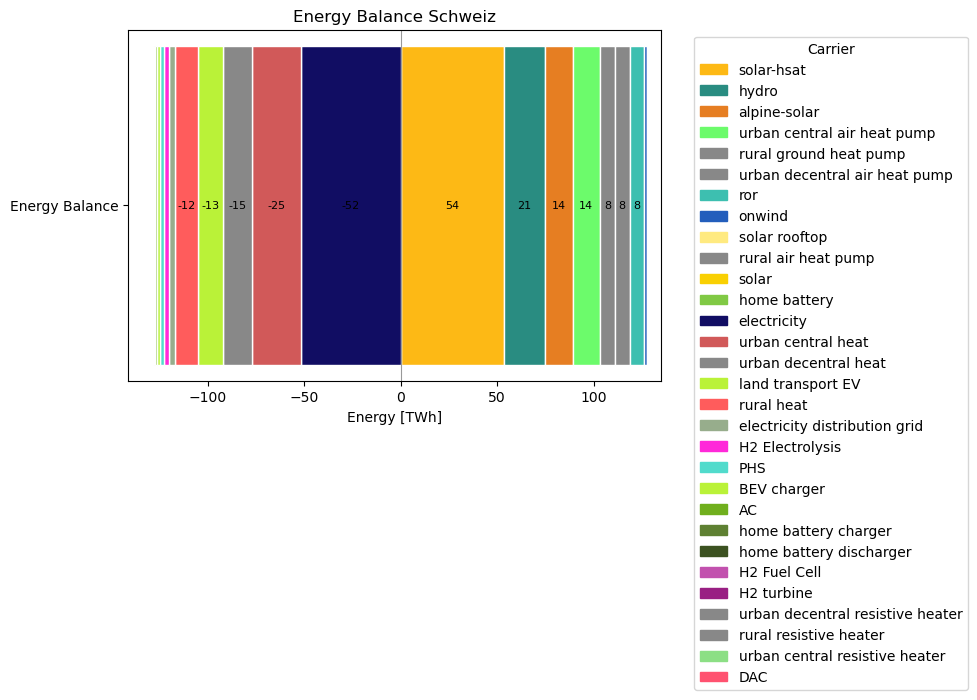

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Bus-level balance holen, CH filtern, nach carrier summieren
energy_balance_bus = stats.energy_balance(drop_zero=False, nice_names=False, groupby=["bus", "carrier"])

ch_mask = energy_balance_bus.index.get_level_values("bus").str.startswith("CH")
energy_balance_ch = (
    energy_balance_bus[ch_mask]
    .groupby("carrier")
    .sum()
    .round(3)
)

stacked_barh_signed(
    energy_balance_ch / 1e6,  # TWh
    ax,
    tech_colors=pypsa_carrier_colors,
    y_label="Energy Balance",
)

ax.set_title("Energy Balance Schweiz")
ax.set_xlabel("Energy [TWh]")

plt.tight_layout()
plt.show()


In [14]:
# Nettoimporte Schweiz
print(energy_balance_ch.loc['AC'])  # positiv = Import, negativ = Export

-969571.626


In [15]:
print(n.global_constraints)


                                                      type  investment_period  \
name                                                                            
lc_limit                 transmission_expansion_cost_limit                NaN   
CO2Limit                                    co2_atmosphere                NaN   
co2_sequestration_limit                  operational_limit                NaN   

                        bus carrier_attribute sense      constant   mu  
name                                                                    
lc_limit                               AC, DC    <=  2.911398e+09  0.0  
CO2Limit                        co2_emissions    <=  0.000000e+00  0.0  
co2_sequestration_limit       co2 sequestered    >= -2.500000e+08  0.0  


## Capacities for Switzerland

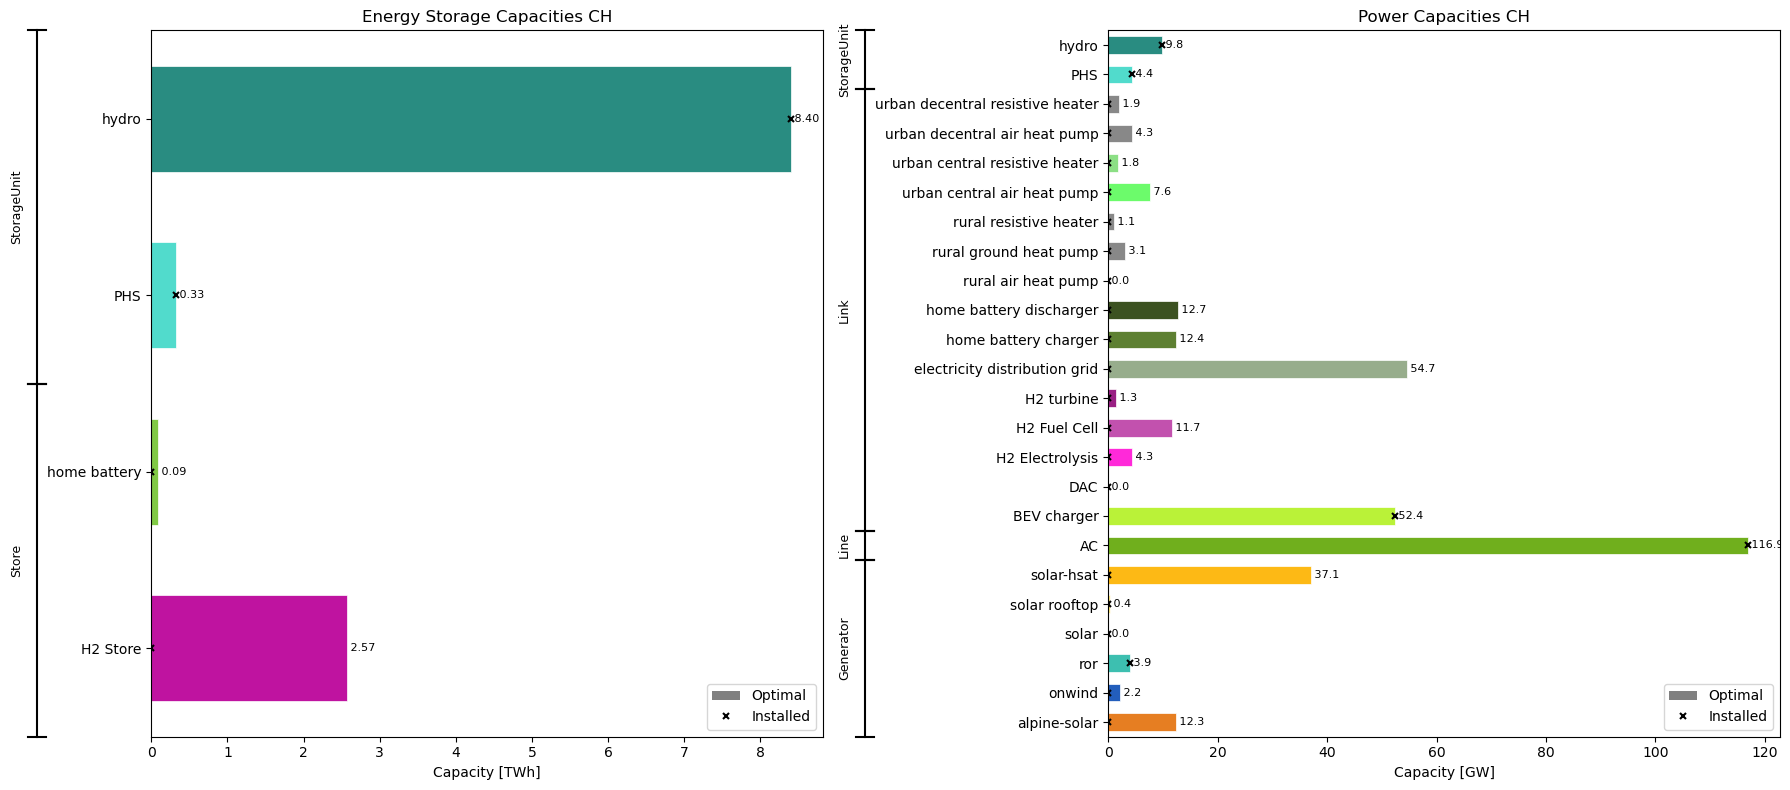

In [16]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)


fig, ax = plt.subplots(1, 2, figsize=(18, 8))

def ch_only_carrier(n, c,**kwargs):
    """Groupby-Callable: gibt carrier nur für CH-Busse zurück, rest NaN → wird ignoriert."""
    df = n.df(c)
    bus_col = "bus" if "bus" in df.columns else "bus0"
    return df["carrier"].where(df[bus_col].str.startswith("CH"))

# Energy capacities (with storage)
inst_energy = stats.installed_capacity(drop_zero=False, nice_names=False, round=3, groupby=ch_only_carrier, storage=True)
opt_energy  = stats.optimal_capacity( drop_zero=False, nice_names=False, round=3, groupby=ch_only_carrier, storage=True)
energy_df = pd.DataFrame({"Installed": inst_energy, "Optimal": opt_energy})

plot_barh(
    energy_df / 1e6,
    ax[0],
    comparison=True, lower_col="Installed", upper_col="Optimal",
    tech_colors=pypsa_carrier_colors,
    xlabel="Capacity [TWh]", title="Energy Storage Capacities CH",
    annotate_decimals=2,
)

# Power capacities (without storage)
inst_power = stats.installed_capacity(drop_zero=False, nice_names=False, round=3, groupby=ch_only_carrier).drop("Store", errors="ignore")
opt_power  = stats.optimal_capacity( drop_zero=False, nice_names=False, round=3, groupby=ch_only_carrier).drop("Store", errors="ignore")
power_df = pd.DataFrame({"Installed": inst_power, "Optimal": opt_power})

plot_barh(
    power_df / 1e3,
    ax[1],
    comparison=True, lower_col="Installed", upper_col="Optimal",
    tech_colors=pypsa_carrier_colors,
    xlabel="Capacity [GW]", title="Power Capacities CH",
)

plt.tight_layout()
plt.show()


## Costs for Switzerland

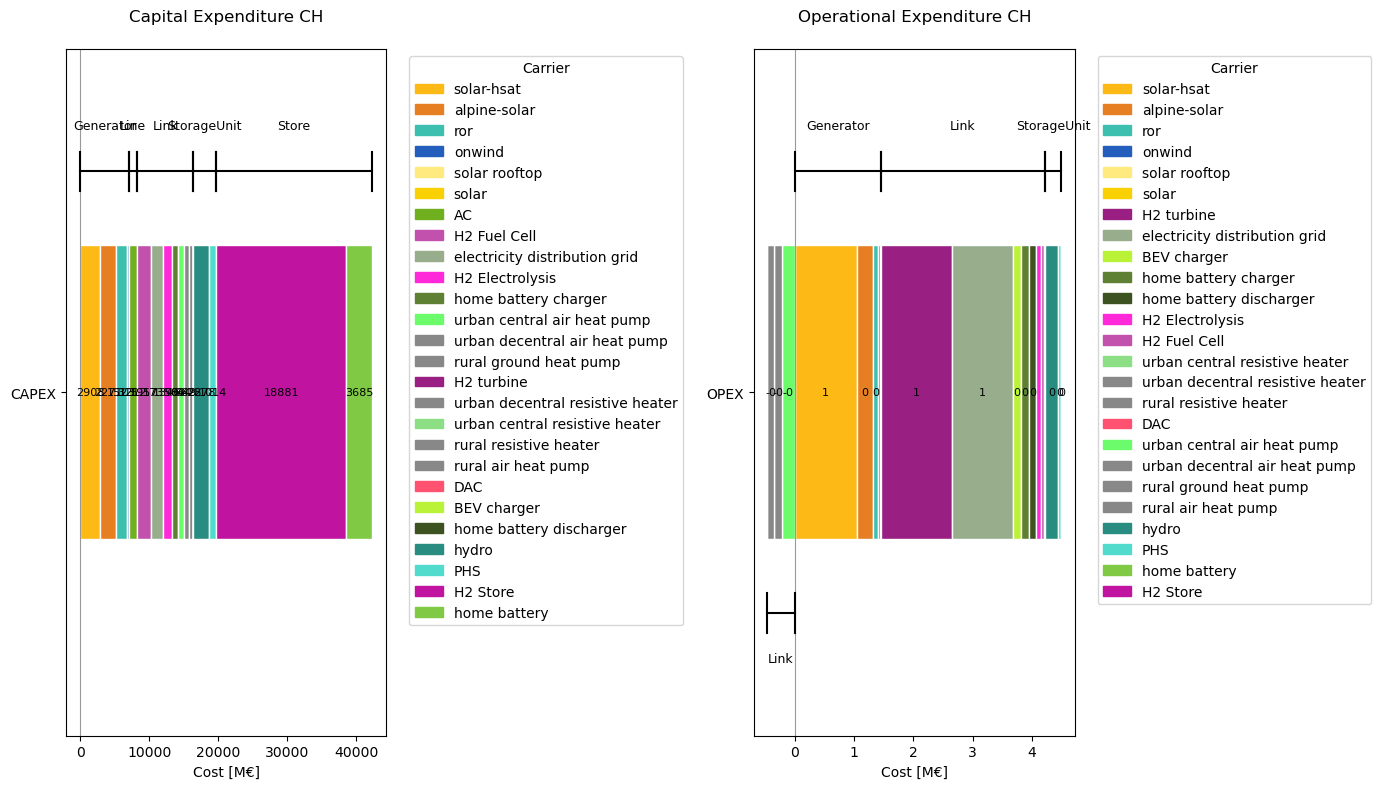

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

def ch_only_carrier(n, c, **kwargs):
    df = n.df(c)
    bus_col = "bus" if "bus" in df.columns else "bus0"
    return df["carrier"].where(df[bus_col].str.startswith("CH"))

capex = stats.capex(drop_zero=False, nice_names=False, round=3, groupby=ch_only_carrier)
opex  = stats.opex( drop_zero=False, nice_names=False, round=3, groupby=ch_only_carrier)

stacked_barh_signed(capex / 1e6, ax[0], tech_colors=pypsa_carrier_colors,
    y_label="CAPEX", title="Capital Expenditure CH")
ax[0].set_xlabel("Cost [M€]")

stacked_barh_signed(opex / 1e6, ax[1], tech_colors=pypsa_carrier_colors,
    y_label="OPEX", title="Operational Expenditure CH")
ax[1].set_xlabel("Cost [M€]")

plt.tight_layout()
plt.show()


# Load shedding

No load shedding columns found in Network


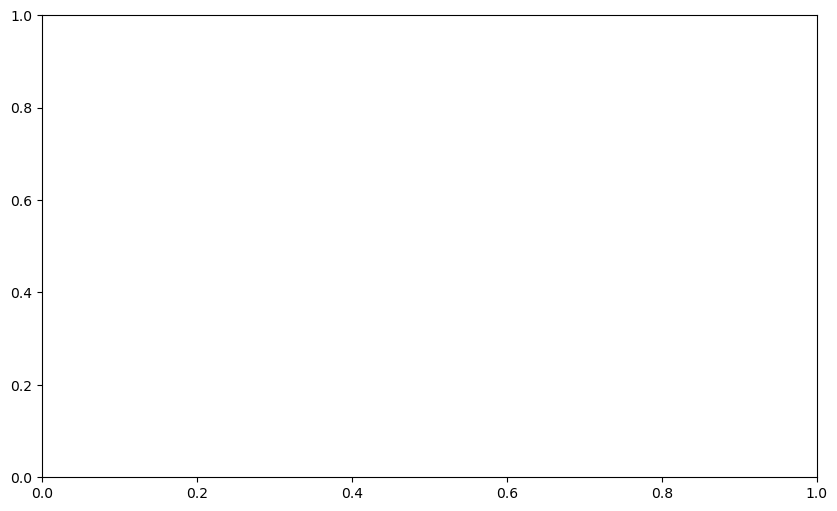

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))


df = n.generators_t["p"]

shedding_cols = df.columns[df.columns.str.contains("load")]

if shedding_cols.empty:
    print("No load shedding columns found in Network")
else:
    shedding_p = df[shedding_cols]
    mul(n.snapshot_weightings["generators"], axis=0)
    s = (shedding_p.sum() / 1e6).sort_values()
    s.plot(kind="barh", ax=ax)
    ax.set_xlabel("Energy [TWh]")
    ax.set_title("Load Shedding")
    plt.tight_layout()
    plt.show()

# Nodes

In [19]:
n.plot.iplot()

{'data': [{'x': AT                         0.589148
   CH011                      0.000900
   CH012                      0.005290
   CH013                      0.136987
   CH021+1                   -0.262495
                                ...   
   IT rural heat              0.246735
   IT urban decentral heat    0.246735
   EU methanol               -0.161527
   EU oil                    -0.117628
   EU gas                    -0.179086
   Name: x, Length: 200, dtype: float64,
   'y': AT                        -0.202836
   CH011                     -0.084308
   CH012                      0.258105
   CH013                      0.051779
   CH021+1                   -0.154547
                                ...   
   IT rural heat              0.003490
   IT urban decentral heat    0.016660
   EU methanol                0.556619
   EU oil                     0.547839
   EU gas                     0.539059
   Name: y, Length: 200, dtype: float64,
   'text': Index(['Bus AT', 'Bus CH011', '

# Timeseries

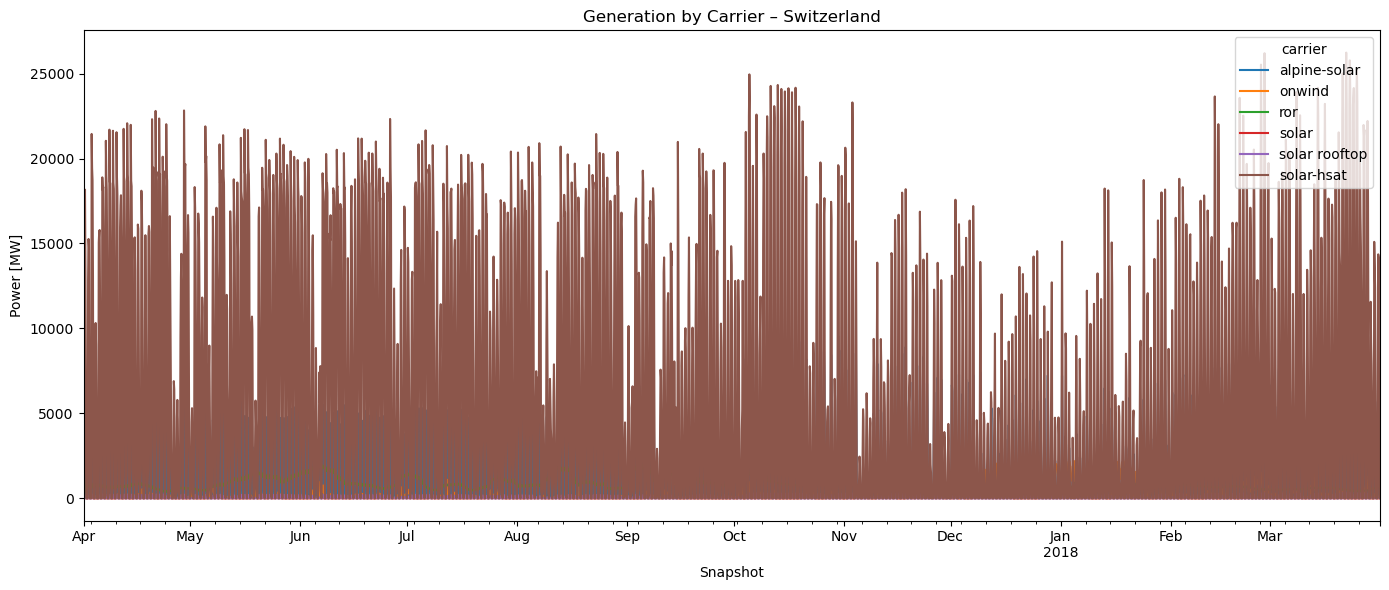

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

# only CH-generators, group by carrier and sum
ch_gens = n.generators[n.generators.bus.str.startswith("CH")].index
gen_t = n.generators_t.p[ch_gens].groupby(n.generators.loc[ch_gens, "carrier"], axis=1).sum()
gen_t.plot(ax=ax)

ax.set_xlabel("Snapshot")
ax.set_ylabel("Power [MW]")
ax.set_title("Generation by Carrier – Switzerland")
plt.tight_layout()
plt.show()


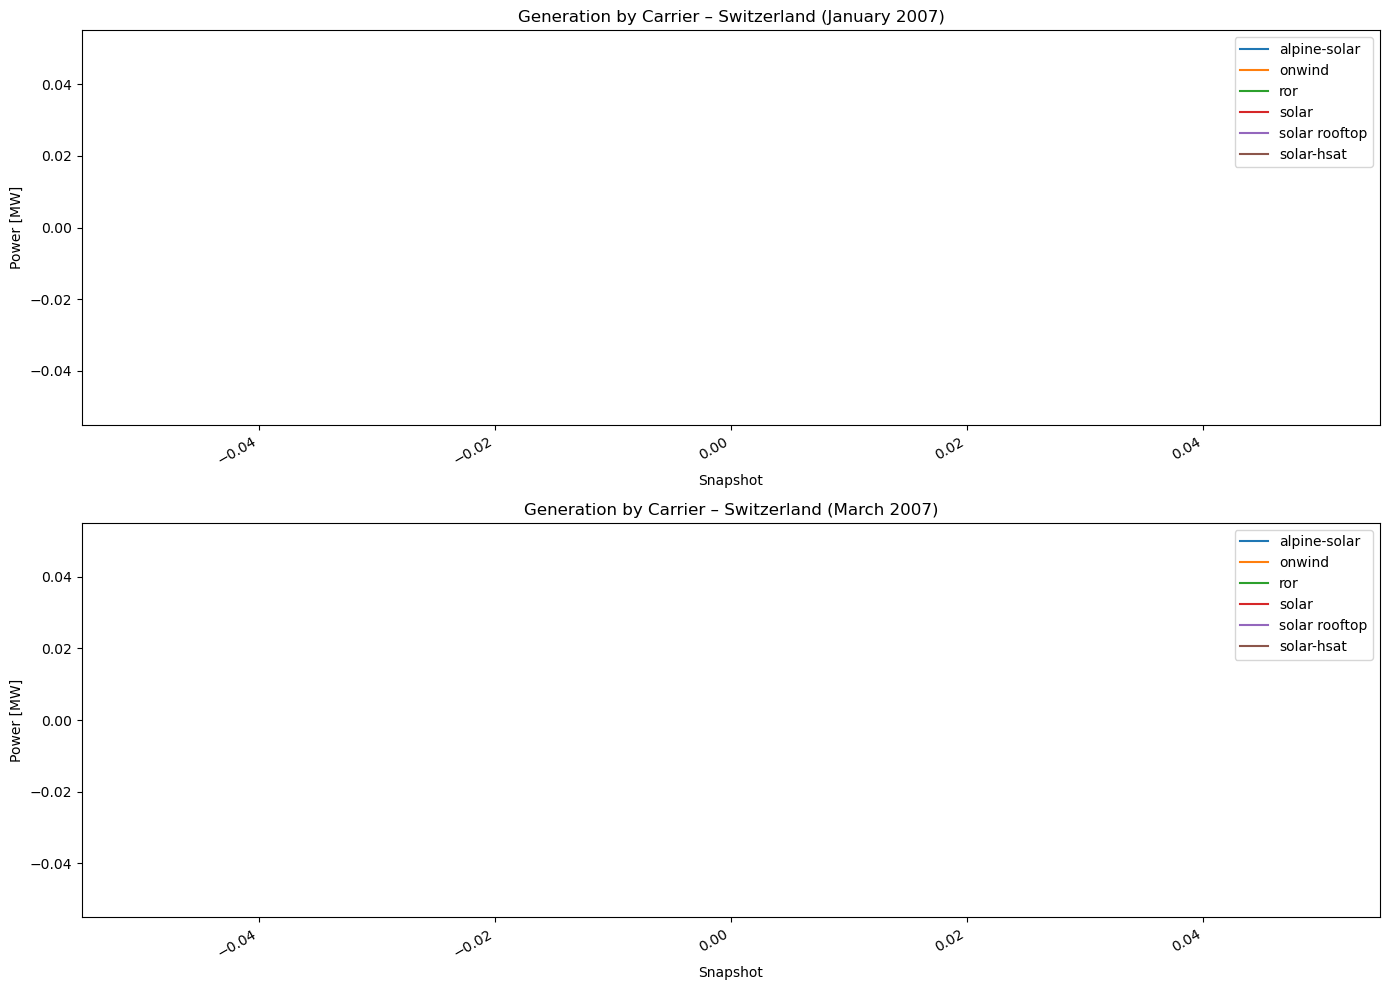

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ch_gens = n.generators[n.generators.bus.str.startswith("CH")].index
gen_t = n.generators_t.p[ch_gens].groupby(n.generators.loc[ch_gens, "carrier"], axis=1).sum()

gen_t["2007-01-01":"2007-01-31"].plot(ax=axes[0])
axes[0].set_title("Generation by Carrier – Switzerland (January 2007)")
axes[0].set_ylabel("Power [MW]")

gen_t["2007-03-01":"2007-03-31"].plot(ax=axes[1])
axes[1].set_title("Generation by Carrier – Switzerland (March 2007)")
axes[1].set_ylabel("Power [MW]")

for ax in axes:
    ax.set_xlabel("Snapshot")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()